## Intern Task 2: Disease Prediction from Medical Data

### Step 1: Setup and Data Loading

In [16]:
# ── Load the dataset ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cancer   = load_breast_cancer()
df       = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target   # 0 = Malignant, 1 = Benign

print("Shape:", df.shape)
print("\nTarget classes:", cancer.target_names)   # ['malignant' 'benign']
print("\nClass distribution:")
print(df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))

Shape: (569, 31)

Target classes: ['malignant' 'benign']

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


### Step 2: Initial Data Exploration

Now, let's get a basic understanding of our data, including its structure, data types, and any missing values.

In [5]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\n--- DataFrame Info ---")
df.info()

# Check for missing values in each column
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Display basic statistical details for numerical columns
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  sm

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Step 3: Data Preprocessing

In [15]:
# Identify target variable (y) and features (X)
# 'target' is the disease outcome (0 for benign, 1 for malignant)
X = df.drop('target', axis=1)  # Features
y = df['target']              # Target variable

# Split the dataset into training and testing sets
# We'll use 80% of the data for training and 20% for testing
# `random_state` ensures reproducibility
# `stratify=y` ensures that the proportion of target classes is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# Scale numerical features
# It's important to scale *after* splitting to prevent data leakage (where information from the test set 'leaks' into the training process)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit scaler on training data and transform it
X_test_scaled = scaler.transform(X_test)     # Transform test data using the *same* scaler

print("\nFeatures scaled successfully.")

# Display the first few rows of the scaled training data (as a DataFrame for readability)
print("\nFirst 5 rows of scaled training features:")
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())


Training set size: 455 samples
Testing set size: 114 samples

Features scaled successfully.

First 5 rows of scaled training features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,...,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
1,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,...,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
2,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,...,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
3,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,...,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
4,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,...,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


### Step 4: Model Training - Logistic Regression

In [7]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# `random_state` ensures reproducibility
# `solver='liblinear'` is a good choice for smaller datasets and binary classification
model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Step 5: Model Evaluation - Logistic Regression

In [8]:
# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

# Calculate accuracy: the proportion of correctly predicted instances
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Display classification report: provides precision, recall, f1-score, and support for each class
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Display confusion matrix: a table showing the number of true positive, true negative, false positive, and false negative predictions
print("\n--- Confusion Matrix ---")
conf_matrix = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(conf_matrix,
                     index=['Actual Benign', 'Actual Malignant'],
                     columns=['Predicted Benign', 'Predicted Malignant']))



Model Accuracy: 0.9825

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- Confusion Matrix ---


,Predicted Benign,Predicted Malignant
Actual Benign,41,1
Actual Malignant,1,71


### Step 6: Implementing Random Forest Classifier

Now, let's train and evaluate a Random Forest Classifier to see how it performs compared to Logistic Regression.

In [9]:
# Import the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

print("RandomForestClassifier imported successfully.")

RandomForestClassifier imported successfully.


In [10]:
# Initialize the Random Forest Classifier
# `random_state` ensures reproducibility
# You can adjust `n_estimators` (number of trees) and other parameters for tuning
rf_model = RandomForestClassifier(random_state=42, n_estimators=100) # Using 100 trees as a default

# Train the model using the scaled training data
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [11]:
# Make predictions on the scaled test data using Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate accuracy for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Model Accuracy: {accuracy_rf:.4f}")

# Display classification report for Random Forest
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# Display confusion matrix for Random Forest
print("\n--- Random Forest Confusion Matrix ---")
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
display(pd.DataFrame(conf_matrix_rf,
                     index=['Actual Benign', 'Actual Malignant'],
                     columns=['Predicted Benign', 'Predicted Malignant']))


Random Forest Model Accuracy: 0.9561

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Random Forest Confusion Matrix ---


,Predicted Benign,Predicted Malignant
Actual Benign,39,3
Actual Malignant,2,70


### Model Performance Visualization

Let's visualize the accuracy of both models to easily compare their performance.

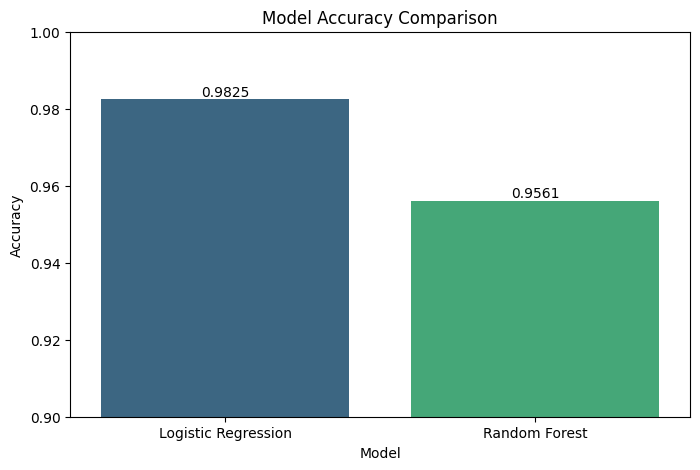

From the visualization, you can clearly see the difference in accuracy between the Logistic Regression and Random Forest models for this dataset.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
model_names = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy, accuracy_rf]

# Create a DataFrame for easy plotting with seaborn
performance_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=performance_df, palette='viridis', legend=False)
plt.title('Model Accuracy Comparison')
plt.ylim(0.9, 1.0) # Set y-axis limits to focus on the differences
plt.ylabel('Accuracy')

# Add accuracy values on top of the bars
for index, row in performance_df.iterrows():
    plt.text(index, row['Accuracy'], f"{row['Accuracy']:.4f}", color='black', ha="center", va='bottom')

plt.show()

print("From the visualization, you can clearly see the difference in accuracy between the Logistic Regression and Random Forest models for this dataset.")